## Project framing

**Track:** Representation Challenge (Track 2)

**Main research question:**
What low-dimensional representations of physiological biosignals best capture 
meaningful variation related to emotional state, and to what extent does this 
variation reflect transient experimental conditions versus stable inter-individual 
differences?

**Sub-questions:**
1. Variance decomposition: How much variance in biosignal features is driven by 
   inter-subject differences vs. by experimental phase?
2. Linear representations: Do PCA representations make experimental phase 
   separable, and does separability improve when individual baselines are removed?
3. Cross-modal structure: To what extent are biosignal features and self-reported 
   emotion ratings linearly related? (CCA)
4. Non-linear representations: Do t-SNE/UMAP reveal structure invisible to linear 
   methods?

**Limitations lens (running throughout):**
What conclusions can be drawn given the noise and inter-subject variation, 
and what would be needed to draw stronger ones?

**Scope decision:** Deferred. Tentative ordering of priority:
PCA + variance decomposition (must) > CCA (high priority) > non-linear (nice-to-have)

## Preprocessing pipeline

**Decision A — Feature scope:** Two views.
- Biosignal view: 51 features (used for PCA, t-SNE, UMAP, and as one view in CCA)
- Emotion view: 11 ratings (used as labels for interpretation, and as one view in CCA)
- Metadata (Round, Phase, Individual, Cohort, Team_ID, Puzzler) used only as labels

**Decision B — Missing values:**
- Drop the 1 row with missing EDA timing features (Individual 23, round 4, phase 1) → biosignal view = 311 rows
- Drop the 4 additional rows with missing emotion ratings only when running CCA → CCA = 307 rows

**Decision C — Scaler choice:** Diagnostic-then-commit.
- Compare StandardScaler vs RobustScaler on a quick PCA diagnostic
- Pick one based on: (1) similarity of leading components, (2) outlier influence on top loadings
- Commit to one scaler for the rest of the project; document the diagnostic briefly in the report

**Decision D — Standardization scope:** Three pipelines compared.
- D1: Global (statistics from all 311 rows)
- D2: Per-subject (each individual's own mean/std across their 12 rows)
- D3: Baseline-relative (subtract each individual's resting-phase mean, optionally divide by resting-phase std)
- All three run for sub-question 2 (does separability improve when individual baselines are removed?)

Biosignal view shape: (311, 70)


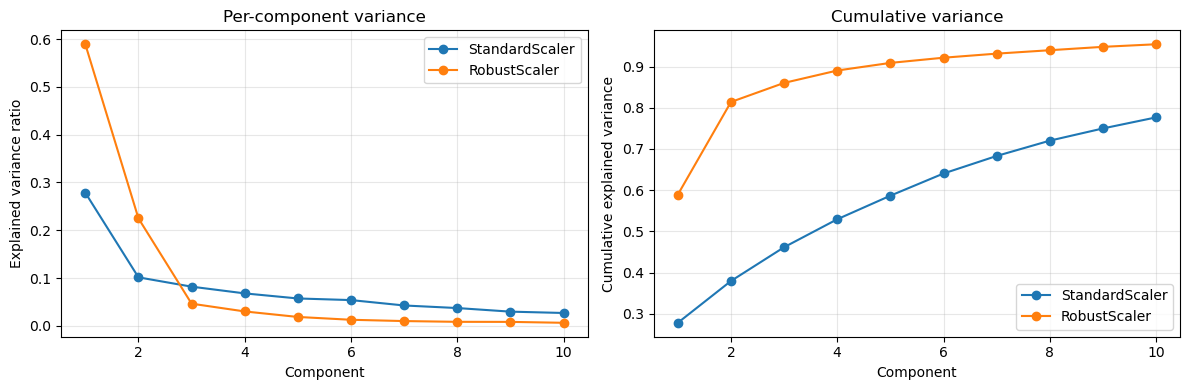


=== Top |loadings| on PC1 ===
                    StandardScaler  RobustScaler
EDA_TD_P_Median              0.205         0.571
EDA_TD_P_Min                 0.101         0.555
EDA_TD_P_Slope               0.176         0.399
EDA_TD_P_AUC                 0.225         0.256
EDA_TD_P_Mean                0.224         0.253
EDA_TD_P_Max                 0.249         0.055
EDA_TD_P_std                 0.246         0.071
EDA_TD_T_std                 0.241         0.068
EDA_TD_T_Slope_max           0.239         0.066
EDA_TD_P_Slope_max           0.238         0.050

=== Top |loadings| on PC2 ===
                 StandardScaler  RobustScaler
EDA_TD_P_Min              0.017         0.815
EDA_TD_P_Median           0.173         0.441
HR_TD_Max                 0.321         0.013
HR_TD_Mean                0.311         0.014
HR_TD_Median              0.285         0.014
HR_TD_AUC                 0.281         0.011
EDA_TD_T_Min              0.247         0.008
HR_TD_std                 0.237

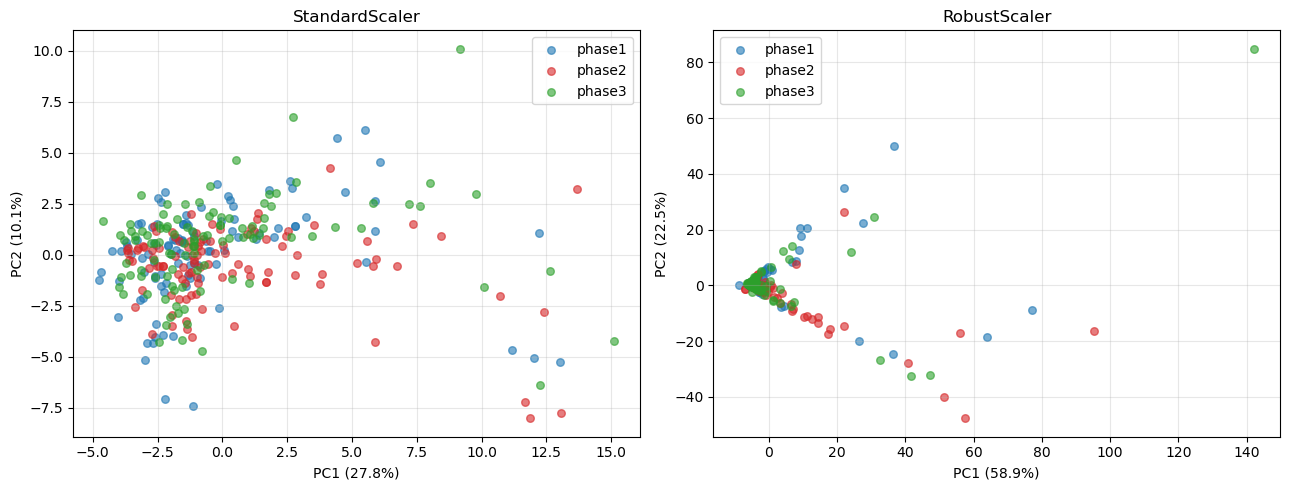

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

# --- Load and prepare data ---
df = pd.read_csv("HR_data_2.csv", index_col=0)

# Define column groups
metadata_cols = ['Round', 'Phase', 'Individual', 'Puzzler', 'original_ID', 
                 'raw_data_path', 'Team_ID', 'Cohort']
emotion_cols = ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 
                'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']
biosignal_cols = [c for c in df.columns if c not in metadata_cols + emotion_cols]

# Drop the 1 row with missing EDA timing features
biosignal_view = df.dropna(subset=biosignal_cols).copy()
print(f"Biosignal view shape: {biosignal_view.shape}")

X = biosignal_view[biosignal_cols].values
phase_labels = biosignal_view['Phase'].values
individual_labels = biosignal_view['Individual'].values

# --- Run PCA with both scalers ---
results = {}
for scaler_name, scaler in [('StandardScaler', StandardScaler()), 
                             ('RobustScaler', RobustScaler())]:
    X_scaled = scaler.fit_transform(X)
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    results[scaler_name] = {
        'X_pca': X_pca,
        'explained_var': pca.explained_variance_ratio_,
        'components': pca.components_,
        'pca': pca
    }

# --- Comparison 1: Explained variance curves ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, r in results.items():
    ax[0].plot(range(1, 11), r['explained_var'][:10], 'o-', label=name)
    ax[1].plot(range(1, 11), np.cumsum(r['explained_var'][:10]), 'o-', label=name)
ax[0].set_xlabel('Component'); ax[0].set_ylabel('Explained variance ratio')
ax[0].set_title('Per-component variance'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_xlabel('Component'); ax[1].set_ylabel('Cumulative explained variance')
ax[1].set_title('Cumulative variance'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Comparison 2: Top loadings on PC1 and PC2 ---
for pc_idx in [0, 1]:
    print(f"\n=== Top |loadings| on PC{pc_idx+1} ===")
    comparison = pd.DataFrame({
        'StandardScaler': pd.Series(
            np.abs(results['StandardScaler']['components'][pc_idx]), 
            index=biosignal_cols
        ),
        'RobustScaler': pd.Series(
            np.abs(results['RobustScaler']['components'][pc_idx]), 
            index=biosignal_cols
        )
    })
    # Top 10 features by either scaler
    top_features = (comparison.max(axis=1)
                    .sort_values(ascending=False).head(10).index)
    print(comparison.loc[top_features].round(3))

# --- Comparison 3: 2D scatter colored by phase ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
phase_colors = {'phase1': 'tab:blue', 'phase2': 'tab:red', 'phase3': 'tab:green'}
for ax, (name, r) in zip(axes, results.items()):
    for ph, color in phase_colors.items():
        mask = phase_labels == ph
        ax.scatter(r['X_pca'][mask, 0], r['X_pca'][mask, 1], 
                   c=color, label=ph, alpha=0.6, s=30)
    ax.set_xlabel(f"PC1 ({r['explained_var'][0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({r['explained_var'][1]*100:.1f}%)")
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Scaler diagnostic (preprocessing decision)

Compared StandardScaler vs RobustScaler on the global-standardization (D1) pipeline.

**Finding:** RobustScaler dramatically amplified outlier influence rather than 
reducing it. With RobustScaler, PC1 alone explained 59% of variance and was 
dominated by three EDA-phasic features (EDA_TD_P_Median: 0.57, EDA_TD_P_Min: 0.56, 
EDA_TD_P_Slope: 0.40). The 2D scatter showed a tight blob with a long outlier arm. 
With StandardScaler, variance was more evenly distributed (PC1: 28%, PC2: 10%) 
and loadings spread across multiple features.

**Mechanism:** EDA-phasic features have tight bulks centered near zero with rare 
sharp spikes. RobustScaler's median/IQR scaling tightens the bulk further, making 
outliers *more* extreme on the rescaled axis. PCA then latches onto the resulting 
high-variance dimensions.

**Decision:** Commit to StandardScaler for the rest of the analysis. 
Acknowledge remaining sensitivity to outliers in EDA-phasic features as a 
known limitation; investigate whether specific rows drive leading components.

In [2]:
# Use StandardScaler PCA results from previous step
pca_results = results['StandardScaler']
X_pca = pca_results['X_pca']

# --- Question 1: Rows extreme on multiple features ---
# Z-score each feature, then count how many features each row is "extreme" on
from sklearn.preprocessing import StandardScaler
X_z = StandardScaler().fit_transform(X)
extreme_count = (np.abs(X_z) > 3).sum(axis=1)  # count of features where |z| > 3

print("Rows with most features in extreme tails (|z| > 3):")
extreme_df = biosignal_view[['Individual', 'Round', 'Phase']].copy()
extreme_df['n_extreme_features'] = extreme_count
extreme_df = extreme_df.sort_values('n_extreme_features', ascending=False)
print(extreme_df.head(10).to_string())

# --- Question 2: Rows driving PC1 ---
print("\nRows with most extreme PC1 values:")
pc1_df = biosignal_view[['Individual', 'Round', 'Phase']].copy()
pc1_df['PC1'] = X_pca[:, 0]
pc1_df['abs_PC1'] = np.abs(X_pca[:, 0])
pc1_df = pc1_df.sort_values('abs_PC1', ascending=False)
print(pc1_df.head(10).to_string())

# --- Question 3: How concentrated is PC1's variance in a few rows? ---
# What fraction of total PC1 squared deviation comes from the top-k rows?
pc1_sq = X_pca[:, 0] ** 2
total = pc1_sq.sum()
print(f"\nFraction of PC1 variance from top rows:")
for k in [1, 3, 5, 10, 20]:
    top_k_sum = np.sort(pc1_sq)[-k:].sum()
    print(f"  Top {k:3d} rows: {top_k_sum/total*100:.1f}%  "
          f"(uniform would be {k/len(pc1_sq)*100:.1f}%)")

Rows with most features in extreme tails (|z| > 3):
     Individual    Round   Phase  n_extreme_features
214          18  round_1  phase2                  12
216          19  round_3  phase3                  12
222          19  round_4  phase3                  12
217          19  round_3  phase2                  11
224          19  round_4  phase1                  11
218          19  round_3  phase1                  10
227          19  round_1  phase1                  10
238          20  round_1  phase2                   9
223          19  round_4  phase2                   9
29            3  round_2  phase1                   8

Rows with most extreme PC1 values:
     Individual    Round   Phase        PC1    abs_PC1
222          19  round_4  phase3  15.104333  15.104333
214          18  round_1  phase2  13.664500  13.664500
217          19  round_3  phase2  13.063275  13.063275
224          19  round_4  phase1  13.015031  13.015031
225          19  round_1  phase3  12.630008  12.630008

In [3]:
# What features are Individual 19's recordings extreme on?
ind19_mask = biosignal_view['Individual'] == 19
ind19_X = X[ind19_mask]
others_X = X[~ind19_mask]

# For each feature, compare Ind 19's median to others' median, in std-units
ind19_median = np.median(ind19_X, axis=0)
others_median = np.median(others_X, axis=0)
others_std = np.std(others_X, axis=0)

# Avoid divide-by-zero
others_std_safe = np.where(others_std > 0, others_std, 1)
diff_in_stds = (ind19_median - others_median) / others_std_safe

ind19_diff = pd.Series(diff_in_stds, index=biosignal_cols).abs().sort_values(ascending=False)
print("Features where Individual 19's median differs most from everyone else's:")
print("(in units of others' std)")
print(ind19_diff.head(10))

# Now look at Individual 18, round 1, phase 2 specifically
ind18_row_mask = ((biosignal_view['Individual'] == 18) & 
                  (biosignal_view['Round'] == 'round_1') & 
                  (biosignal_view['Phase'] == 'phase2'))
ind18_row = X[ind18_row_mask][0]

# Compare to the median across all other rows
others_full_median = np.median(X[~ind18_row_mask], axis=0)
others_full_std = np.std(X[~ind18_row_mask], axis=0)
others_full_std_safe = np.where(others_full_std > 0, others_full_std, 1)
ind18_z = (ind18_row - others_full_median) / others_full_std_safe

ind18_diff = pd.Series(np.abs(ind18_z), index=biosignal_cols).sort_values(ascending=False)
print("\nFeatures where Individual 18 round_1 phase2 is most extreme:")
print("(z-score relative to everyone else)")
print(ind18_diff.head(10))

Features where Individual 19's median differs most from everyone else's:
(in units of others' std)
EDA_TD_P_Median        13.970010
EDA_TD_P_Mean          11.106457
EDA_TD_P_AUC           10.482322
EDA_TD_P_Slope_mean     7.720881
EDA_TD_P_Slope          6.396174
EDA_TD_P_Max            5.158486
EDA_TD_P_Slope_max      5.133482
EDA_TD_P_std            4.927930
EDA_TD_T_std            4.709185
EDA_TD_T_Slope_max      4.705089
dtype: float64

Features where Individual 18 round_1 phase2 is most extreme:
(z-score relative to everyone else)
EDA_TD_T_AUC          7.796918
EDA_TD_T_Max          6.147271
EDA_TD_T_Mean         5.842429
EDA_TD_T_Median       5.420498
EDA_TD_T_std          5.337480
EDA_TD_T_Min          5.310802
EDA_TD_P_Slope_min    4.381004
EDA_TD_P_Slope_max    3.722562
EDA_TD_T_Slope        3.521868
EDA_TD_P_Max          3.505761
dtype: float64


## Outlier diagnostic (preprocessing)

Investigated whether specific rows or individuals dominate the leading PCA components.

**Findings:**
- Top 10 rows (3% of data) account for 37% of PC1 variance under global 
  standardization — far above the 3% expected under uniform contribution.
- 9 of the top 10 PC1-extreme rows belong to Individual 19. Investigation showed 
  Individual 19's extremeness is concentrated entirely in EDA-phasic and EDA-tonic 
  features (medians 5–14 std above the population), with normal HR and TEMP. 
  Consistent with the known phenomenon of large inter-individual EDA reactivity.
- Individual 18 (round 1, phase 2) is extreme on tonic EDA only — likely a strong 
  stress response to the first puzzle attempt, with no signs of sensor artifact.

**Decision:** No outliers removed. Both cases reflect genuine physiological 
variation rather than measurement error. The presence of these effects motivates 
the comparison of global (D1) vs per-subject (D2) vs baseline-relative (D3) 
standardization in the main analysis: D2 and D3 should remove inter-subject 
EDA reactivity differences, allowing phase structure to become more visible.